# Poultry public image-based disease detection baseline experiment

This notebook is designed as a small, reproducible experiment to support the literature review conclusion.

The goal is to test several common image classification models on an image dataset for known poultry diseases and compare the model performance against oneanother and baselines from the PRISMA literature review using a common accuracy-equivalent metric.


**Primary focus:** public fecal image datasets:

- **Machuve/Zenodo PCR-annotated poultry fecal image dataset**
- Expected classes: `Healthy`, `Coccidiosis`, `NCD`, `Salmonella`
- Link: `https://zenodo.org/records/5801834`

- **allandclive annotated poultry fecal image dataset**
- Expected classes: `Healthy`, `Coccidiosis`, `NCD`, `Salmonella`
- Link: `https://www.kaggle.com/datasets/allandclive/chicken-disease-1/data?suggestionBundleId=1679`

The notebook compares multiple image-classification models on the same local dataset split and reports both overall and per-disease metrics.

## Experiment design

The reviewed literature reports several image-based disease classification results using public or public-like poultry fecal image datasets. Where the papers report direct accuracy, test accuracy, or validation accuracy, those values are treated as **accuracy-equivalent** for charting and baseline comparison.

Important comparability note:

- Accuracy/test accuracy/validation accuracy are used as the common comparison metric.
- Metrics such as `mAP@0.5` are **not** converted into accuracy.
- Different papers may use different dataset versions, train/validation/test splits, augmentation, and class balancing. The comparison is therefore used to justify the experiment choice, not as a formal meta-analysis.

In [5]:
# Requirements
# This will need to be installed locally, or if running in collab should work by just uncomment the line below
# !pip install -q tensorflow scikit-learn pandas matplotlib seaborn pillow

In [6]:

import os
import json
import math
import shutil
import random
from pathlib import Path
from datetime import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from collections import defaultdict

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    classification_report,
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)
print("GPU devices:", tf.config.list_physical_devices("GPU"))


TensorFlow: 2.20.0
GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 1. Literature baseline table

This table is used to decide which public dataset/model combination is reasonable for the experiment.

The four disease-specific charts are built by expanding the same model results across the disease classes included in the dataset. This is necessary because most papers report **overall multiclass accuracy**, not disease-specific accuracy. Where class-level precision/recall/F1 is available, those should be added separately to the `class_level_results` table after running the experiment.


In [7]:
overall_literature_baselines = [
    {
        "Paper": "Himel & Islam (2025)",
        "Dataset_Group": "Machuve / Zenodo PCR-annotated poultry fecal images",
        "Class_Set": "Healthy, Cocci, NCD, Salmo",
        "Model": "DenseNet121",
        "Overall_Test_Accuracy": 0.8964,
        "Metric_Basis": "Overall 4-class test accuracy",
        "Comparable_To_Prototype_Overall": True,
        "Notes": "Overall model result, not disease-specific."
    },
    {
        "Paper": "Himel & Islam (2025)",
        "Dataset_Group": "Machuve / Zenodo PCR-annotated poultry fecal images",
        "Class_Set": "Healthy, Cocci, NCD, Salmo",
        "Model": "MobileNet",
        "Overall_Test_Accuracy": 0.8821,
        "Metric_Basis": "Overall 4-class test accuracy",
        "Comparable_To_Prototype_Overall": True,
        "Notes": "Overall model result, not disease-specific."
    },
    {
        "Paper": "Himel & Islam (2025)",
        "Dataset_Group": "Machuve / Zenodo PCR-annotated poultry fecal images",
        "Class_Set": "Healthy, Cocci, NCD, Salmo",
        "Model": "MobileNetV2",
        "Overall_Test_Accuracy": 0.8571,
        "Metric_Basis": "Overall 4-class test accuracy",
        "Comparable_To_Prototype_Overall": True,
        "Notes": "Overall model result, not disease-specific."
    },
    {
        "Paper": "Himel & Islam (2025)",
        "Dataset_Group": "Machuve / Zenodo PCR-annotated poultry fecal images",
        "Class_Set": "Healthy, Cocci, NCD, Salmo",
        "Model": "Xception",
        "Overall_Test_Accuracy": 0.8678,
        "Metric_Basis": "Overall 4-class test accuracy",
        "Comparable_To_Prototype_Overall": True,
        "Notes": "Overall model result, not disease-specific."
    },
    {
        "Paper": "Himel & Islam (2025)",
        "Dataset_Group": "Machuve / Zenodo PCR-annotated poultry fecal images",
        "Class_Set": "Healthy, Cocci, NCD, Salmo",
        "Model": "Stacking ensemble + Extra Trees",
        "Overall_Test_Accuracy": 0.9901,
        "Metric_Basis": "Overall 4-class test accuracy",
        "Comparable_To_Prototype_Overall": True,
        "Notes": "Ensemble result."
    }
]

overall_baseline_df = pd.DataFrame(overall_literature_baselines)
overall_baseline_df["Overall_Test_Accuracy_Percent"] = overall_baseline_df["Overall_Test_Accuracy"] * 100
display(overall_baseline_df)

,Paper,Dataset_Group,Class_Set,Model,Overall_Test_Accuracy,Metric_Basis,Comparable_To_Prototype_Overall,Notes,Overall_Test_Accuracy_Percent
0,Himel & Islam (2025),Machuve / Zenodo PCR-annotated poultry fecal i...,"Healthy, Cocci, NCD, Salmo",DenseNet121,0.8964,Overall 4-class test accuracy,True,"Overall model result, not disease-specific.",89.64
1,Himel & Islam (2025),Machuve / Zenodo PCR-annotated poultry fecal i...,"Healthy, Cocci, NCD, Salmo",MobileNet,0.8821,Overall 4-class test accuracy,True,"Overall model result, not disease-specific.",88.21
2,Himel & Islam (2025),Machuve / Zenodo PCR-annotated poultry fecal i...,"Healthy, Cocci, NCD, Salmo",MobileNetV2,0.8571,Overall 4-class test accuracy,True,"Overall model result, not disease-specific.",85.71
3,Himel & Islam (2025),Machuve / Zenodo PCR-annotated poultry fecal i...,"Healthy, Cocci, NCD, Salmo",Xception,0.8678,Overall 4-class test accuracy,True,"Overall model result, not disease-specific.",86.78
4,Himel & Islam (2025),Machuve / Zenodo PCR-annotated poultry fecal i...,"Healthy, Cocci, NCD, Salmo",Stacking ensemble + Extra Trees,0.9901,Overall 4-class test accuracy,True,Ensemble result.,99.01


In [8]:
disease_literature_baselines = [
    # DenseNet121
    {"Paper": "Himel & Islam (2025)", "Disease": "Healthy", "Model": "DenseNet121", "Precision": 0.86, "Recall": 0.86, "F1": 0.86},
    {"Paper": "Himel & Islam (2025)", "Disease": "Coccidiosis", "Model": "DenseNet121", "Precision": 0.91, "Recall": 0.83, "F1": 0.87},
    {"Paper": "Himel & Islam (2025)", "Disease": "Newcastle disease (NCD)", "Model": "DenseNet121", "Precision": 0.96, "Recall": 0.97, "F1": 0.96},
    {"Paper": "Himel & Islam (2025)", "Disease": "Salmonella", "Model": "DenseNet121", "Precision": 0.87, "Recall": 0.93, "F1": 0.90},

    # MobileNetV2
    {"Paper": "Himel & Islam (2025)", "Disease": "Healthy", "Model": "MobileNetV2", "Precision": 0.76, "Recall": 0.84, "F1": 0.80},
    {"Paper": "Himel & Islam (2025)", "Disease": "Coccidiosis", "Model": "MobileNetV2", "Precision": 0.89, "Recall": 0.81, "F1": 0.85},
    {"Paper": "Himel & Islam (2025)", "Disease": "Newcastle disease (NCD)", "Model": "MobileNetV2", "Precision": 0.94, "Recall": 0.97, "F1": 0.96},
    {"Paper": "Himel & Islam (2025)", "Disease": "Salmonella", "Model": "MobileNetV2", "Precision": 0.85, "Recall": 0.80, "F1": 0.82},

    # Xception
    {"Paper": "Himel & Islam (2025)", "Disease": "Healthy", "Model": "Xception", "Precision": 0.78, "Recall": 0.90, "F1": 0.83},
    {"Paper": "Himel & Islam (2025)", "Disease": "Coccidiosis", "Model": "Xception", "Precision": 0.92, "Recall": 0.79, "F1": 0.85},
    {"Paper": "Himel & Islam (2025)", "Disease": "Newcastle disease (NCD)", "Model": "Xception", "Precision": 0.97, "Recall": 0.89, "F1": 0.93},
    {"Paper": "Himel & Islam (2025)", "Disease": "Salmonella", "Model": "Xception", "Precision": 0.84, "Recall": 0.90, "F1": 0.87},

    # Stacking ensemble + Extra Trees
    {"Paper": "Himel & Islam (2025)", "Disease": "Healthy", "Model": "Stacking ensemble + Extra Trees", "Precision": 0.9859, "Recall": 1.0000, "F1": 0.9929},
    {"Paper": "Himel & Islam (2025)", "Disease": "Coccidiosis", "Model": "Stacking ensemble + Extra Trees", "Precision": 1.0000, "Recall": 0.9857, "F1": 0.9928},
    {"Paper": "Himel & Islam (2025)", "Disease": "Newcastle disease (NCD)", "Model": "Stacking ensemble + Extra Trees", "Precision": 0.9859, "Recall": 1.0000, "F1": 0.9929},
    {"Paper": "Himel & Islam (2025)", "Disease": "Salmonella", "Model": "Stacking ensemble + Extra Trees", "Precision": 1.0000, "Recall": 0.9857, "F1": 0.9928},
]

disease_baseline_df = pd.DataFrame(disease_literature_baselines)

for col in ["Precision", "Recall", "F1"]:
    disease_baseline_df[f"{col}_Percent"] = disease_baseline_df[col] * 100

display(disease_baseline_df)

,Paper,Disease,Model,Precision,Recall,F1,Precision_Percent,Recall_Percent,F1_Percent
0,Himel & Islam (2025),Healthy,DenseNet121,0.8600,0.8600,0.8600,86.00,86.00,86.00
1,Himel & Islam (2025),Coccidiosis,DenseNet121,0.9100,0.8300,0.8700,91.00,83.00,87.00
2,Himel & Islam (2025),Newcastle disease (NCD),DenseNet121,0.9600,0.9700,0.9600,96.00,97.00,96.00
3,Himel & Islam (2025),Salmonella,DenseNet121,0.8700,0.9300,0.9000,87.00,93.00,90.00
4,Himel & Islam (2025),Healthy,MobileNetV2,0.7600,0.8400,0.8000,76.00,84.00,80.00
5,Himel & Islam (2025),Coccidiosis,MobileNetV2,0.8900,0.8100,0.8500,89.00,81.00,85.00
6,Himel & Islam (2025),Newcastle disease (NCD),MobileNetV2,0.9400,0.9700,0.9600,94.00,97.00,96.00
7,Himel & Islam (2025),Salmonella,MobileNetV2,0.8500,0.8000,0.8200,85.00,80.00,82.00
8,Himel & Islam (2025),Healthy,Xception,0.7800,0.9000,0.8300,78.00,90.00,83.00
9,Himel & Islam (2025),Coccidiosis,Xception,0.9200,0.7900,0.8500,92.00,79.00,85.00


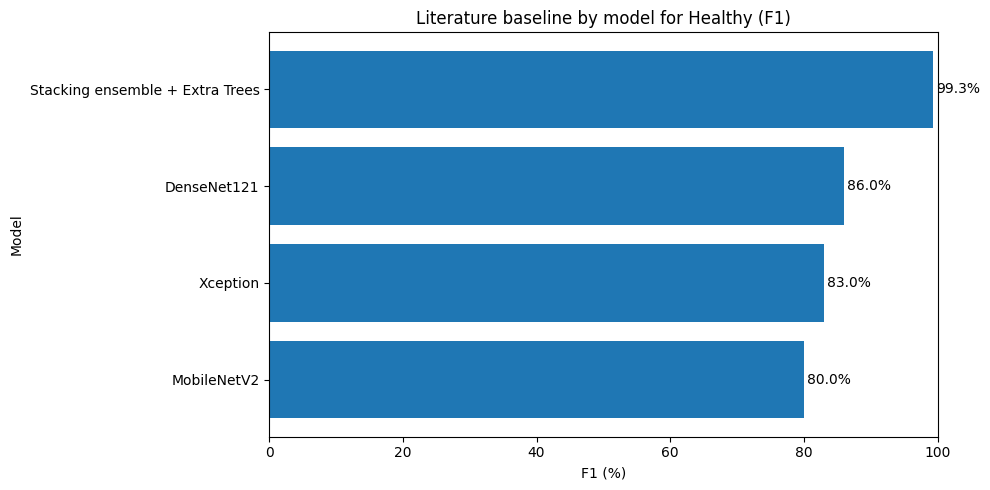

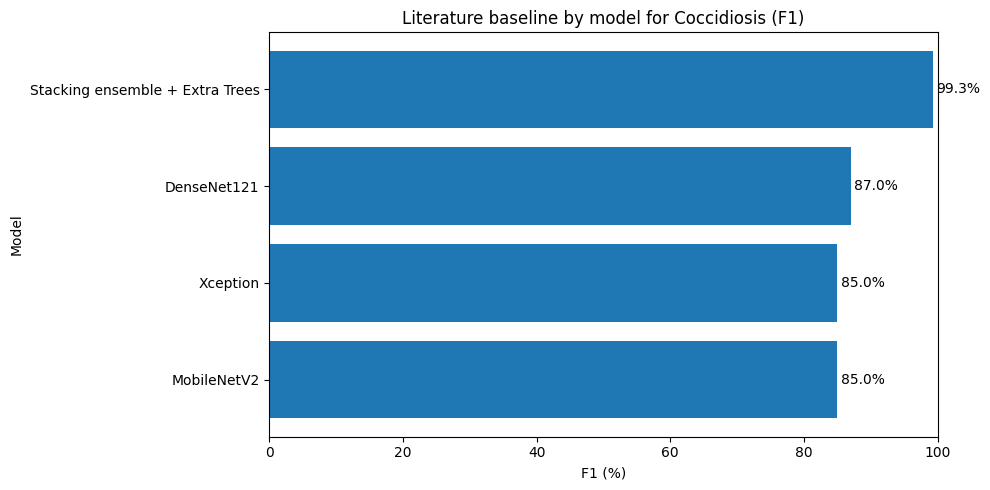

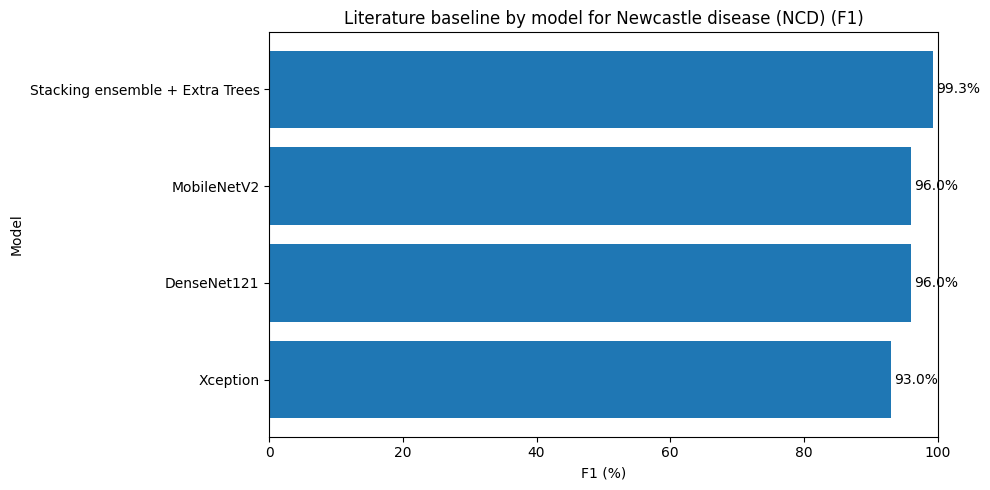

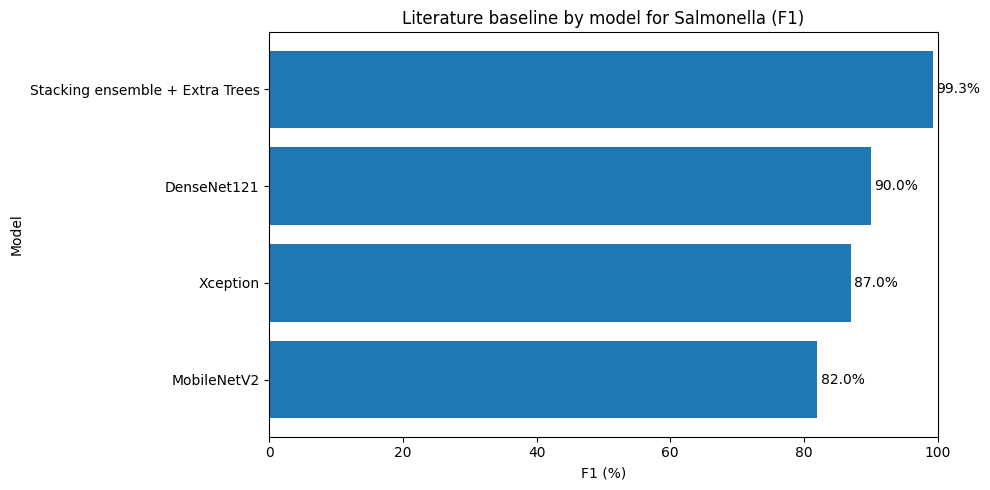

In [9]:
#Plot disease-specific literature baselines.
#These plots are useful for the report but should be interpreted as overall model accuracy for a multiclass task containing the disease, not per-disease accuracy.

def plot_disease_baseline_metric(disease_name, metric="F1"):
    plot_df = disease_baseline_df[disease_baseline_df["Disease"] == disease_name].copy()
    plot_df = plot_df.sort_values(metric, ascending=True)

    plt.figure(figsize=(10, 5))
    plt.barh(plot_df["Model"], plot_df[metric] * 100)
    plt.xlabel(f"{metric} (%)")
    plt.ylabel("Model")
    plt.title(f"Literature baseline by model for {disease_name} ({metric})")
    plt.xlim(0, 100)

    for i, value in enumerate(plot_df[metric] * 100):
        plt.text(value + 0.5, i, f"{value:.1f}%", va="center")

    plt.tight_layout()
    plt.show()

for disease in disease_baseline_df["Disease"].unique():
    plot_disease_baseline_metric(disease, metric="F1")

## 2. Dataset setup

Place the public fecal image dataset into the following folder structure.

```text
dataset/
  Healthy/
  Cocci/
  NCD/
  Salmo/
```

Class names can be adjusted below if the downloaded dataset uses slightly different folder names.


In [ ]:
# Globals
DATASET_NAME = "allandclive"  # vlaid dataset names for this prototype: machuve-zenodo, allandclive
IMG_DIR = Path(f"./data/poultry_fecal_dataset/{DATASET_NAME}")  # change this as required
OUTPUT_DIR = Path(f"./data/poultry_experiment_outputs/{DATASET_NAME}_{datetime.now().strftime('%Y%m%d_%H%M%S')}") #to persist multiple output versions without overwriting. Adjust as needed.
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
LOG_DIR =  Path(f"{OUTPUT_DIR}/logs")
MODEL_DIR = Path(f"{OUTPUT_DIR}/models")
for folder in [LOG_DIR, MODEL_DIR]:
    folder.mkdir(parents=True, exist_ok=True)
SAVE_MODEL = True  # when True, saves best model weights to OUTPUT_DIR/models
IMG_SIZE = (224, 224) # standard size for many pretrained models used in the literature. Adjsut as required.
BATCH_SIZE = 64 # smaller batch size can help with memory constraints, especially on limited hardware. 64 worked fine on my GPU with 8GB VRAM for 224x224 images
EPOCHS = 25  # main training epochs
FINE_TUNE = False  # toggle fine-tuning of pretrained transfer-learning models after initial training. THIS IS NOT IMPLEMENTED in this prototype but can be added as needed.
FINE_TUNE_EPOCHS = 5
FINE_TUNE_LEARNING_RATE = 1e-5
FINE_TUNE_LAST_N_LAYERS = 30  #unfreeze only the final N layers of the pretrained base model - this as just an example and varies widly based on the model
TRAIN_RATIO = 0.75
VAL_RATIO = 0.15
TEST_RATIO = 0.10



# Define class aliases to standardize class names across different datasets and papers.
CLASS_ALIASES = {
    "Healthy": ["Healthy", "healthy", "Normal", "normal"],
    "Coccidiosis": ["Cocci", "Coccidiosis", "cocci", "coccidiosis", "Crcocci"],
    "Newcastle disease (NCD)": ["NCD", "ncd", "Newcastle", "Newcastle disease", "New Castle Disease", "newcastle", "newcastle disease", "new castle disease"],
    "Salmonella": ["Salmo", "salmo", "Salmonella", "salmonella"],
}

assert IMG_DIR.exists(), f"Dataset folder not found: {IMG_DIR}. Upload or mount the dataset first."
print("Classes/folders found:", [p.name for p in IMG_DIR.iterdir() if p.is_dir()])


Classes/folders found: ['chicken-disease-1']


Perform startified split of dataset

In [11]:
# Utility functions for splitting, saving and then loading the dataset for reproducibility and consistency.
def canonical_class_name(value: str):
    value = str(value).strip()

    for canonical_name, aliases in CLASS_ALIASES.items():
        if value in aliases:
            return canonical_name

    return value

def collect_class_files(root_dir: Path):
    if DATASET_NAME == "allandclive":
        csv_path = root_dir / "chicken-disease-1" / "train_data.csv"
        image_dir = root_dir / "chicken-disease-1" / "Train"

        df = pd.read_csv(csv_path)

        records_unindexed = []

        for _, row in df.iterrows():
            image_name = str(row["images"]).strip()
            class_name = canonical_class_name(row["label"])
            image_path = image_dir / image_name

            if not image_path.exists():
                print(f"Warning: file not found: {image_path}")
                continue

            records_unindexed.append({
                "path": str(image_path),
                "class_name": class_name,
            })

        class_names = sorted(CLASS_ALIASES.keys())
        class_to_index = {class_name: idx for idx, class_name in enumerate(class_names)}

        records = []

        for record in records_unindexed:
            records.append({
                "path": record["path"],
                "class_name": record["class_name"],
                "class_index": class_to_index[record["class_name"]],
            })

        return records, class_names

    # Default folder-per-class structure, used by machuve-zenodo
    class_dirs = sorted([p for p in root_dir.iterdir() if p.is_dir()])

    raw_class_names = [p.name for p in class_dirs]
    class_names = sorted(CLASS_ALIASES.keys())
    class_to_index = {class_name: idx for idx, class_name in enumerate(class_names)}

    records = []

    for class_dir in class_dirs:
        class_name = canonical_class_name(class_dir.name)
        class_index = class_to_index[class_name]

        image_files = sorted([p for p in class_dir.rglob("*") if p.is_file()])

        for image_path in image_files:
            records.append({
                "path": str(image_path),
                "class_name": class_name,
                "class_index": class_index,
            })

    return records, class_names

# Stratified split function to maintain class distribution across train/val/test sets. 
def stratified_train_val_test_split(records, train_ratio=0.75, val_ratio=0.15):
    train_records = []
    val_records = []
    test_records = []

    class_names = sorted(set(record["class_name"] for record in records))

    for class_name in class_names:
        class_records = [record for record in records if record["class_name"] == class_name]
        class_records = class_records.copy()
        random.shuffle(class_records)

        train_end = int(train_ratio * len(class_records))
        val_end = int((train_ratio + val_ratio) * len(class_records))

        train_records.extend(class_records[:train_end])
        val_records.extend(class_records[train_end:val_end])
        test_records.extend(class_records[val_end:])

    random.shuffle(train_records)
    random.shuffle(val_records)
    random.shuffle(test_records)

    return train_records, val_records, test_records

#build TensorFlow datasets directly from file paths, with on-the-fly loading and preprocessing. This is more memory efficient and allows for larger datasets without needing to load everything into memory at once.
def records_to_dataset(records, shuffle=False):
    paths = [record["path"] for record in records]
    labels = [record["class_index"] for record in records]

    ds = tf.data.Dataset.from_tensor_slices((paths, labels))

    if shuffle:
        ds = ds.shuffle(buffer_size=len(paths), seed=SEED, reshuffle_each_iteration=True)

    def load_image(path, label):
        image = tf.io.read_file(path)
        image = tf.image.decode_image(image, channels=3, expand_animations=False)
        image = tf.image.resize(image, IMG_SIZE)
        image = tf.cast(image, tf.float32)
        return image, label

    ds = ds.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(BATCH_SIZE)

    return ds

#validations
def count_records_by_class(records, split_name):
    df = pd.DataFrame(records)

    if df.empty:
        return pd.DataFrame(columns=["split", "class_name", "count"])

    counts = (
        df.groupby("class_name")
        .size()
        .reset_index(name="count")
        .sort_values("class_name")
    )

    counts.insert(0, "split", split_name)
    return counts


def count_dataset_classes(dataset, class_names):
    counts = {name: 0 for name in class_names}

    for _, labels in dataset:
        for label in labels.numpy():
            counts[class_names[int(label)]] += 1

    return counts

records, class_names = collect_class_files(IMG_DIR)
num_classes = len(class_names)

source_counts = (
    pd.DataFrame(records)
    .groupby("class_name")
    .size()
    .reset_index(name="count")
    .sort_values("class_name")
)

#actually do the stratified split
train_records, val_records, test_records = stratified_train_val_test_split(records,train_ratio=TRAIN_RATIO,val_ratio=VAL_RATIO,)

split_counts_df = pd.concat(
    [
        count_records_by_class(train_records, "train"),
        count_records_by_class(val_records, "val"),
        count_records_by_class(test_records, "test"),
    ],
    ignore_index=True,
)

print(f"Total files found: {len(records)}")
print("Class distribution in original dataset:")
display(source_counts)
print("Class distribution after stratified split:")
display(split_counts_df)

#Build TensorFlow datasets directly from paths
train_ds = records_to_dataset(train_records, shuffle=True)
val_ds = records_to_dataset(val_records, shuffle=False)
test_ds = records_to_dataset(test_records, shuffle=False)

# Cache and prefetch for performance - remove if memory issues
train_ds = train_ds.cache().prefetch(tf.data.AUTOTUNE)
val_ds = val_ds.cache().prefetch(tf.data.AUTOTUNE)
test_ds = test_ds.cache().prefetch(tf.data.AUTOTUNE)

#debug check shapes and labels for one batch
#for images, labels in train_ds.take(1):
#    print("Image batch shape:", images.shape)
#    print("Label batch shape:", labels.shape)
#    print("Example labels:", labels[:10].numpy())

Total files found: 8067
Class distribution in original dataset:


,class_name,count
0,Coccidiosis,2476
1,Healthy,2404
2,Newcastle disease (NCD),562
3,Salmonella,2625


Class distribution after stratified split:


,split,class_name,count
0,train,Coccidiosis,1857
1,train,Healthy,1803
2,train,Newcastle disease (NCD),421
3,train,Salmonella,1968
4,val,Coccidiosis,371
5,val,Healthy,360
6,val,Newcastle disease (NCD),84
7,val,Salmonella,394
8,test,Coccidiosis,248
9,test,Healthy,241


I0000 00:00:1780659815.878429   87785 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5555 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3070 Ti, pci bus id: 0000:01:00.0, compute capability: 8.6


## 3. Model definitions

The experiment deliberately uses well-known Keras application models so the result is reproducible and easy to explain.

Recommended first run:

- Small custom CNN baseline
- MobileNetV2
- DenseNet121
- EfficientNetB0
- ResNet50
- Xception
- ViT_Tiny
- VGG19

Optional heavier models can be added later if runtime allows.


In [12]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.1),
], name="data_augmentation")

#simple CNN architecture for baseline comparison
def build_small_cnn(num_classes: int) -> keras.Model:
    inputs = keras.Input(shape=(*IMG_SIZE, 3))
    x = layers.Rescaling(1./255)(inputs)
    x = data_augmentation(x)
    x = layers.Conv2D(32, 3, activation="relu")(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Conv2D(64, 3, activation="relu")(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Conv2D(128, 3, activation="relu")(x)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)
    return keras.Model(inputs, outputs, name="Small_CNN")


def build_transfer_model(model_name: str, num_classes: int) -> keras.Model:
    constructors = {
        "MobileNetV2": keras.applications.MobileNetV2,
        "DenseNet121": keras.applications.DenseNet121,
        "EfficientNetB0": keras.applications.EfficientNetB0,
        "Xception": keras.applications.Xception,
        "ResNet50": keras.applications.ResNet50,
        "VGG19": keras.applications.VGG19,
    }

    preprocessors = {
        "MobileNetV2": keras.applications.mobilenet_v2.preprocess_input,
        "DenseNet121": keras.applications.densenet.preprocess_input,
        "EfficientNetB0": keras.applications.efficientnet.preprocess_input,
        "Xception": keras.applications.xception.preprocess_input,
        "ResNet50": keras.applications.resnet50.preprocess_input,
        "VGG19": keras.applications.vgg19.preprocess_input,
    }

    base_constructor = constructors[model_name]
    preprocess = preprocessors[model_name]

    inputs = keras.Input(shape=(*IMG_SIZE, 3))
    x = data_augmentation(inputs)
    x = layers.Lambda(preprocess, name=f"{model_name}_preprocess")(x)

    base = base_constructor(
        include_top=False,
        weights="imagenet",
        input_shape=(*IMG_SIZE, 3),
    )
    base._name = f"{model_name}_base"
    base.trainable = False

    x = base(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)

    return keras.Model(inputs, outputs, name=model_name)

#small self-contained Vision Transformer option.
#This is intentionally lightweight so it can run in the same notebook without extra KerasHub dependencies.
class PatchExtractor(layers.Layer):
    def __init__(self, patch_size, **kwargs):
        super().__init__(**kwargs)
        self.patch_size = patch_size

    def call(self, images):
        batch_size = tf.shape(images)[0]
        patches = tf.image.extract_patches(
            images=images,
            sizes=[1, self.patch_size, self.patch_size, 1],
            strides=[1, self.patch_size, self.patch_size, 1],
            rates=[1, 1, 1, 1],
            padding="VALID",
        )
        patch_dims = patches.shape[-1]
        return tf.reshape(patches, [batch_size, -1, patch_dims])


class PatchEncoder(layers.Layer):
    def __init__(self, num_patches, projection_dim, **kwargs):
        super().__init__(**kwargs)
        self.num_patches = num_patches
        self.projection = layers.Dense(units=projection_dim)
        self.position_embedding = layers.Embedding(
            input_dim=num_patches,
            output_dim=projection_dim,
        )

    def call(self, patches):
        positions = tf.range(start=0, limit=self.num_patches, delta=1)
        encoded = self.projection(patches) + self.position_embedding(positions)
        return encoded


def build_vit_tiny(num_classes: int) -> keras.Model:
    patch_size = 16
    projection_dim = 64
    transformer_layers = 4
    num_heads = 4
    mlp_dim = 128
    dropout_rate = 0.2
    num_patches = (IMG_SIZE[0] // patch_size) * (IMG_SIZE[1] // patch_size)

    inputs = keras.Input(shape=(*IMG_SIZE, 3))
    x = layers.Rescaling(1./255)(inputs)
    x = data_augmentation(x)
    patches = PatchExtractor(patch_size, name="patch_extractor")(x)
    encoded_patches = PatchEncoder(num_patches, projection_dim, name="patch_encoder")(patches)

    for i in range(transformer_layers):
        x1 = layers.LayerNormalization(epsilon=1e-6, name=f"vit_ln1_{i}")(encoded_patches)
        attention_output = layers.MultiHeadAttention(
            num_heads=num_heads,
            key_dim=projection_dim,
            dropout=dropout_rate,
            name=f"vit_mha_{i}",
        )(x1, x1)
        x2 = layers.Add(name=f"vit_skip1_{i}")([attention_output, encoded_patches])

        x3 = layers.LayerNormalization(epsilon=1e-6, name=f"vit_ln2_{i}")(x2)
        x3 = layers.Dense(mlp_dim, activation="gelu", name=f"vit_mlp1_{i}")(x3)
        x3 = layers.Dropout(dropout_rate, name=f"vit_dropout1_{i}")(x3)
        x3 = layers.Dense(projection_dim, activation="gelu", name=f"vit_mlp2_{i}")(x3)
        x3 = layers.Dropout(dropout_rate, name=f"vit_dropout2_{i}")(x3)
        encoded_patches = layers.Add(name=f"vit_skip2_{i}")([x3, x2])

    representation = layers.LayerNormalization(epsilon=1e-6, name="vit_final_ln")(encoded_patches)
    representation = layers.GlobalAveragePooling1D(name="vit_gap")(representation)
    representation = layers.Dropout(0.3)(representation)
    outputs = layers.Dense(num_classes, activation="softmax", dtype="float32")(representation)

    return keras.Model(inputs, outputs, name="ViT_Tiny")

## 4. Training and evaluation functions


In [13]:
#utility functions for 
def compile_model(model: keras.Model, learning_rate: float = 1e-4) -> keras.Model:
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model


def build_training_callbacks(model_name: str, run_suffix: str = ""):
    log_name = f"{model_name}{run_suffix}"
    callbacks = [
        keras.callbacks.EarlyStopping(
            monitor="val_loss",            
            patience=3, #this may need tuning
            restore_best_weights=True,
        ),
        keras.callbacks.TensorBoard(
            log_dir=str(LOG_DIR / log_name),
            histogram_freq=1,
        ),
    ]
    if SAVE_MODEL:
        callbacks.append(
            keras.callbacks.ModelCheckpoint(
                filepath=str(MODEL_DIR / f"{log_name}_best.weights.h5"),
                monitor="val_loss",
                save_best_only=True,
                save_weights_only=True,
                mode="min",
                verbose=1,
            )
        )
    return callbacks


def train_model(model_name: str, model: keras.Model, epochs: int = EPOCHS):
    callbacks = build_training_callbacks(model_name)

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=epochs,
        callbacks=callbacks,
        verbose=1,
    )

    return history


#This is an exmaple of a fine turning implementation for transfer learning models 
#It unfreezes the last N layers of the pretrained base model and continues training with a lower learning rate.
#This is not actually implemented it's just and exmaple and its very rough and would have to be adapted based on the specific architecture of the model and how the base model is integrated.
def fine_tune_model(
    model_name: str,
    model: keras.Model,
    epochs: int = FINE_TUNE_EPOCHS,
    learning_rate: float = FINE_TUNE_LEARNING_RATE,
    unfreeze_last_n: int = FINE_TUNE_LAST_N_LAYERS,
    run_suffix: str = "_finetune",
):

    base_model = None
    for layer in model.layers:
        if isinstance(layer, keras.Model) and layer.name.endswith("_base"):
            base_model = layer
            break

    if base_model is None:
        print(f"No pretrained base model found for {model_name}; skipping fine-tuning.")
        return None

    base_model.trainable = True

    #Keep most pretrained layers frozen. Only unfreeze the final N layers.
    if unfreeze_last_n is not None and unfreeze_last_n > 0:
        for layer in base_model.layers[:-unfreeze_last_n]:
            layer.trainable = False

    #Keep BatchNorm frozen for small datasets; this helps avoid unstable fine-tuning.
    for layer in base_model.layers:
        if isinstance(layer, layers.BatchNormalization):
            layer.trainable = False

    model = compile_model(model, learning_rate=learning_rate)

    callbacks = build_training_callbacks(model_name, run_suffix=run_suffix)

    print(
        f"Fine-tuning {model_name}: "
        f"last {unfreeze_last_n} base layers, learning_rate={learning_rate}"
    )

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=epochs,
        callbacks=callbacks,
        verbose=1,
    )

    return history


#basic evaluation function to collect predictions and compute metrics
def collect_predictions(model: keras.Model, dataset):
    y_true = []
    y_prob = []

    for images, labels in dataset:
        probs = model.predict(images, verbose=0)

        y_true.append(labels.numpy())
        y_prob.append(probs)

    y_true = np.concatenate(y_true, axis=0)
    y_prob = np.concatenate(y_prob, axis=0)

    # Labels are already integer class indexes because label_mode="int"
    y_true_idx = y_true.astype(int)

    # Predictions are probabilities over classes, so use argmax here
    y_pred_idx = np.argmax(y_prob, axis=1)

    return y_true_idx, y_pred_idx, y_prob


def specificity_per_class(cm: np.ndarray):
    specificities = {}
    total = cm.sum()

    for i, label in enumerate(class_names):
        tp = cm[i, i]
        fp = cm[:, i].sum() - tp
        fn = cm[i, :].sum() - tp
        tn = total - tp - fp - fn
        specificity = tn / (tn + fp) if (tn + fp) else np.nan
        specificities[label] = specificity

    return specificities


def evaluate_model(model_name: str, model: keras.Model, dataset):
    y_true, y_pred, y_prob = collect_predictions(model, dataset)

    acc = accuracy_score(y_true, y_pred)
    precision, recall, f1, support = precision_recall_fscore_support(
        y_true,
        y_pred,
        labels=list(range(len(class_names))),
        zero_division=0,
    )

    cm = confusion_matrix(y_true, y_pred, labels=list(range(len(class_names))))
    specificity = specificity_per_class(cm)

    rows = []
    for i, label in enumerate(class_names):
        rows.append({
            "Model": model_name,
            "Class": label,
            "Precision": precision[i],
            "Recall_Sensitivity": recall[i],
            "Specificity": specificity[label],
            "F1": f1[i],
            "Support": int(support[i]),
            "Overall_Accuracy": acc,
        })

    return pd.DataFrame(rows), cm


## 5. Run the experiment

Start with the lightweight models. Add heavier models only if the runtime is acceptable.

TensorBoard logs are stored under OUTPUT_DIR/logs.
View logs with: tensorboard --logdir <path-to-OUTPUT_DIR/logs>


In [14]:
MODELS_TO_RUN = [
    "Small_CNN",
    "MobileNetV2",
    "DenseNet121",
    "EfficientNetB0",
    "Xception",
    "ResNet50",
    "VGG19",
    "ViT_Tiny",
    # additional models can be added here as needed
]

all_class_metrics = []
all_histories = {}
all_fine_tune_histories = {}
confusion_matrices = {}

for model_name in MODELS_TO_RUN:
    print(f"Model: {model_name}")

    if model_name == "Small_CNN":
        model = build_small_cnn(num_classes)
    elif model_name == "ViT_Tiny":
        model = build_vit_tiny(num_classes)
    else:
        model = build_transfer_model(model_name, num_classes)

    model = compile_model(model)
    history = train_model(model_name, model)
    all_histories[model_name] = history.history

    if FINE_TUNE and model_name not in ["Small_CNN", "ViT_Tiny"]:
        fine_tune_history = fine_tune_model(model_name, model)
        if fine_tune_history is not None:
            all_fine_tune_histories[model_name] = fine_tune_history.history

    class_metrics, cm = evaluate_model(model_name, model, test_ds)
    all_class_metrics.append(class_metrics)
    confusion_matrices[model_name] = cm

results_df = pd.concat(all_class_metrics, ignore_index=True)
results_df


Model: Small_CNN
Epoch 1/25


2026-06-05 11:43:40.001600: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 92000


95/95 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - accuracy: 0.3393 - loss: 1.3105
Epoch 1: val_loss improved from None to 1.11177, saving model to data/poultry_experiment_outputs/allandclive_20260605_114334/models/Small_CNN_best.weights.h5

Epoch 1: finished saving model to data/poultry_experiment_outputs/allandclive_20260605_114334/models/Small_CNN_best.weights.h5
95/95 ━━━━━━━━━━━━━━━━━━━━ 16s 125ms/step - accuracy: 0.3996 - loss: 1.2448 - val_accuracy: 0.6336 - val_loss: 1.1118
Epoch 2/25
94/95 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.5248 - loss: 1.0686
Epoch 2: val_loss improved from 1.11177 to 0.97359, saving model to data/poultry_experiment_outputs/allandclive_20260605_114334/models/Small_CNN_best.weights.h5

Epoch 2: finished saving model to data/poultry_experiment_outputs/allandclive_20260605_114334/models/Small_CNN_best.weights.h5
95/95 ━━━━━━━━━━━━━━━━━━━━ 5s 57ms/step - accuracy: 0.5657 - loss: 1.0191 - val_accuracy: 0.6137 - val_loss: 0.9736
Epoch 3/25
95/95 ━━━━━━━━━━━━━━━

2026-06-05 11:45:44.704844: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Model: MobileNetV2
Epoch 1/25
95/95 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.4782 - loss: 1.2492
Epoch 1: val_loss improved from None to 0.75122, saving model to data/poultry_experiment_outputs/allandclive_20260605_114334/models/MobileNetV2_best.weights.h5

Epoch 1: finished saving model to data/poultry_experiment_outputs/allandclive_20260605_114334/models/MobileNetV2_best.weights.h5
95/95 ━━━━━━━━━━━━━━━━━━━━ 11s 84ms/step - accuracy: 0.5576 - loss: 1.1007 - val_accuracy: 0.7502 - val_loss: 0.7512
Epoch 2/25
94/95 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.6730 - loss: 0.8427
Epoch 2: val_loss improved from 0.75122 to 0.58361, saving model to data/poultry_experiment_outputs/allandclive_20260605_114334/models/MobileNetV2_best.weights.h5

Epoch 2: finished saving model to data/poultry_experiment_outputs/allandclive_20260605_114334/models/MobileNetV2_best.weights.h5
95/95 ━━━━━━━━━━━━━━━━━━━━ 7s 75ms/step - accuracy: 0.6980 - loss: 0.7960 - val_accuracy: 0.8089 - val_loss: 0.

...

95/95 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step - accuracy: 0.2913 - loss: 3.0168

2026-06-05 12:13:25.519906: W external/local_xla/xla/tsl/framework/bfc_allocator.cc:310] Allocator (GPU_0_bfc) ran out of memory trying to allocate 3.83GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.



Epoch 1: val_loss improved from None to 1.77142, saving model to data/poultry_experiment_outputs/allandclive_20260605_114334/models/VGG19_best.weights.h5

Epoch 1: finished saving model to data/poultry_experiment_outputs/allandclive_20260605_114334/models/VGG19_best.weights.h5
95/95 ━━━━━━━━━━━━━━━━━━━━ 22s 209ms/step - accuracy: 0.3149 - loss: 2.7241 - val_accuracy: 0.4409 - val_loss: 1.7714
Epoch 2/25
95/95 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step - accuracy: 0.4038 - loss: 2.1499
Epoch 2: val_loss improved from 1.77142 to 1.31481, saving model to data/poultry_experiment_outputs/allandclive_20260605_114334/models/VGG19_best.weights.h5

Epoch 2: finished saving model to data/poultry_experiment_outputs/allandclive_20260605_114334/models/VGG19_best.weights.h5
95/95 ━━━━━━━━━━━━━━━━━━━━ 17s 177ms/step - accuracy: 0.4268 - loss: 2.0116 - val_accuracy: 0.5840 - val_loss: 1.3148
Epoch 3/25
95/95 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step - accuracy: 0.4962 - loss: 1.7282
Epoch 3: val_loss improved from 

2026-06-05 12:22:54.783001: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


,Model,Class,Precision,Recall_Sensitivity,Specificity,F1,Support,Overall_Accuracy
0,Small_CNN,Coccidiosis,0.911215,0.786290,0.966132,0.844156,248,0.730532
1,Small_CNN,Healthy,0.709804,0.751037,0.869718,0.729839,241,0.730532
2,Small_CNN,Newcastle disease (NCD),0.000000,0.000000,1.000000,0.000000,57,0.730532
3,Small_CNN,Salmonella,0.632353,0.817490,0.771062,0.713101,263,0.730532
4,MobileNetV2,Coccidiosis,0.962343,0.927419,0.983957,0.944559,248,0.918418
5,MobileNetV2,Healthy,0.879377,0.937759,0.945423,0.907631,241,0.918418
6,MobileNetV2,Newcastle disease (NCD),0.860465,0.649123,0.992021,0.740000,57,0.918418
7,MobileNetV2,Salmonella,0.925926,0.950570,0.963370,0.938086,263,0.918418
8,DenseNet121,Coccidiosis,0.926070,0.959677,0.966132,0.942574,248,0.898640
9,DenseNet121,Healthy,0.869231,0.937759,0.940141,0.902196,241,0.898640


In [15]:
# Overall model comparison on the same validation split
overall_results = (
    results_df
    .groupby("Model", as_index=False)
    .agg(
        Overall_Accuracy=("Overall_Accuracy", "max"),
        Macro_Precision=("Precision", "mean"),
        Macro_Recall_Sensitivity=("Recall_Sensitivity", "mean"),
        Macro_Specificity=("Specificity", "mean"),
        Macro_F1=("F1", "mean"),
    )
    .sort_values("Overall_Accuracy", ascending=False)
)

overall_results


,Model,Overall_Accuracy,Macro_Precision,Macro_Recall_Sensitivity,Macro_Specificity,Macro_F1
3,ResNet50,0.939431,0.938077,0.900072,0.978401,0.916135
1,EfficientNetB0,0.923362,0.911315,0.869932,0.972800,0.886625
2,MobileNetV2,0.918418,0.907028,0.866218,0.971193,0.882569
0,DenseNet121,0.898640,0.901098,0.793067,0.963541,0.815730
7,Xception,0.894932,0.874447,0.803264,0.962567,0.823885
6,ViT_Tiny,0.889988,0.838545,0.829428,0.962399,0.833469
5,VGG19,0.871446,0.832588,0.777612,0.954429,0.794129
4,Small_CNN,0.730532,0.563343,0.588705,0.901728,0.571774


In [16]:
# Per-class / per-disease results
class_metrics_df = (
    results_df
    .groupby(["Model", "Class"], as_index=False)
    .agg(
        Precision=("Precision", "mean"),
        Recall_Sensitivity=("Recall_Sensitivity", "mean"),
        Specificity=("Specificity", "mean"),
        F1=("F1", "mean"),
        Support=("Support", "sum"),
    )
)
class_metrics_df.sort_values(["Class", "F1"], ascending=[True, False])


,Model,Class,Precision,Recall_Sensitivity,Specificity,F1,Support
12,ResNet50,Coccidiosis,0.948413,0.963710,0.976827,0.956000,248
24,ViT_Tiny,Coccidiosis,0.974468,0.923387,0.989305,0.948240,248
4,EfficientNetB0,Coccidiosis,0.954918,0.939516,0.980392,0.947154,248
8,MobileNetV2,Coccidiosis,0.962343,0.927419,0.983957,0.944559,248
28,Xception,Coccidiosis,0.940000,0.947581,0.973262,0.943775,248
0,DenseNet121,Coccidiosis,0.926070,0.959677,0.966132,0.942574,248
20,VGG19,Coccidiosis,0.930328,0.915323,0.969697,0.922764,248
16,Small_CNN,Coccidiosis,0.911215,0.786290,0.966132,0.844156,248
13,ResNet50,Healthy,0.930041,0.937759,0.970070,0.933884,241
5,EfficientNetB0,Healthy,0.929167,0.925311,0.970070,0.927235,241


In [17]:
#Overall prototype model accuracy vs overall literature baselines
overall_baseline_df = pd.DataFrame(overall_literature_baselines)
overall_baseline_df["Overall_Test_Accuracy_Percent"] = (
    overall_baseline_df["Overall_Test_Accuracy"] * 100
)

best_overall_literature_row = (
    overall_baseline_df
    .sort_values("Overall_Test_Accuracy", ascending=False)
    .iloc[0]
)

best_literature_overall_accuracy = best_overall_literature_row["Overall_Test_Accuracy"]
best_literature_overall_model = best_overall_literature_row["Model"]
best_literature_overall_paper = best_overall_literature_row["Paper"]

prototype_vs_overall_baseline = overall_results.copy()

prototype_vs_overall_baseline["Best_Literature_Model"] = best_literature_overall_model
prototype_vs_overall_baseline["Best_Literature_Paper"] = best_literature_overall_paper
prototype_vs_overall_baseline["Best_Literature_Overall_Accuracy"] = best_literature_overall_accuracy
prototype_vs_overall_baseline["Gap_To_Best_Literature_Accuracy"] = (
    prototype_vs_overall_baseline["Overall_Accuracy"] - best_literature_overall_accuracy
)

prototype_vs_overall_baseline["Overall_Accuracy_Percent"] = (
    prototype_vs_overall_baseline["Overall_Accuracy"] * 100
)

prototype_vs_overall_baseline["Best_Literature_Overall_Accuracy_Percent"] = (
    prototype_vs_overall_baseline["Best_Literature_Overall_Accuracy"] * 100
)

prototype_vs_overall_baseline["Gap_To_Best_Literature_Accuracy_Percent"] = (
    prototype_vs_overall_baseline["Gap_To_Best_Literature_Accuracy"] * 100
)

display(prototype_vs_overall_baseline.sort_values("Overall_Accuracy", ascending=False))

,Model,Overall_Accuracy,Macro_Precision,Macro_Recall_Sensitivity,Macro_Specificity,Macro_F1,Best_Literature_Model,Best_Literature_Paper,Best_Literature_Overall_Accuracy,Gap_To_Best_Literature_Accuracy,Overall_Accuracy_Percent,Best_Literature_Overall_Accuracy_Percent,Gap_To_Best_Literature_Accuracy_Percent
3,ResNet50,0.939431,0.938077,0.900072,0.978401,0.916135,Stacking ensemble + Extra Trees,Himel & Islam (2025),0.9901,-0.050669,93.943140,99.01,-5.066860
1,EfficientNetB0,0.923362,0.911315,0.869932,0.972800,0.886625,Stacking ensemble + Extra Trees,Himel & Islam (2025),0.9901,-0.066738,92.336218,99.01,-6.673782
2,MobileNetV2,0.918418,0.907028,0.866218,0.971193,0.882569,Stacking ensemble + Extra Trees,Himel & Islam (2025),0.9901,-0.071682,91.841780,99.01,-7.168220
0,DenseNet121,0.898640,0.901098,0.793067,0.963541,0.815730,Stacking ensemble + Extra Trees,Himel & Islam (2025),0.9901,-0.091460,89.864030,99.01,-9.145970
7,Xception,0.894932,0.874447,0.803264,0.962567,0.823885,Stacking ensemble + Extra Trees,Himel & Islam (2025),0.9901,-0.095168,89.493201,99.01,-9.516799
6,ViT_Tiny,0.889988,0.838545,0.829428,0.962399,0.833469,Stacking ensemble + Extra Trees,Himel & Islam (2025),0.9901,-0.100112,88.998764,99.01,-10.011236
5,VGG19,0.871446,0.832588,0.777612,0.954429,0.794129,Stacking ensemble + Extra Trees,Himel & Islam (2025),0.9901,-0.118654,87.144623,99.01,-11.865377
4,Small_CNN,0.730532,0.563343,0.588705,0.901728,0.571774,Stacking ensemble + Extra Trees,Himel & Islam (2025),0.9901,-0.259568,73.053152,99.01,-25.956848


In [18]:
#Per-disease prototype metrics vs per-disease literature baselines
disease_baseline_df = pd.DataFrame(disease_literature_baselines)

for col in ["Precision", "Recall", "F1"]:
    disease_baseline_df[f"{col}_Percent"] = disease_baseline_df[col] * 100


#Map prototype dataset class labels to literature disease labels
prototype_class_to_disease = {
    "healthy": "Healthy",
    "cocci": "Coccidiosis",
    "ncd": "Newcastle disease (NCD)",
    "salmo": "Salmonella",
}

#This handles either all_class_metrics or an already-combined class_metrics_df.
if "class_metrics_df" not in globals():
    class_metrics_df = pd.concat(all_class_metrics, ignore_index=True)

prototype_disease_metrics = class_metrics_df.copy()

#this functions as a SQL innerjoin to keep only classes that have a mapping to a disease in the literature baselines. If the literature baselines don't have these then this will be empty or reduced 
prototype_disease_metrics["Disease"] = (prototype_disease_metrics["Class"].astype(str).str.strip().str.lower().map(prototype_class_to_disease))

#Keep rows that mapped successfully
prototype_disease_metrics = prototype_disease_metrics[prototype_disease_metrics["Disease"].notna()].copy()

#Rename prototype metric columns to align with literature naming
prototype_disease_metrics = prototype_disease_metrics.rename(columns={"Recall_Sensitivity": "Recall",})

#Find best literature baseline by disease for each metric.
best_lit_by_disease_f1 = (
    disease_baseline_df
    .sort_values("F1", ascending=False)
    .groupby("Disease", as_index=False)
    .first()
    [[
        "Disease",
        "Paper",
        "Model",
        "Precision",
        "Recall",
        "F1",
    ]]
    .rename(
        columns={
            "Paper": "Best_Literature_Paper",
            "Model": "Best_Literature_Model",
            "Precision": "Best_Literature_Precision",
            "Recall": "Best_Literature_Recall",
            "F1": "Best_Literature_F1",
        }
    )
)


prototype_vs_disease_baseline = prototype_disease_metrics.merge(best_lit_by_disease_f1,on="Disease",how="left")
prototype_vs_disease_baseline["Gap_To_Best_Literature_Precision"] = (prototype_vs_disease_baseline["Precision"] - prototype_vs_disease_baseline["Best_Literature_Precision"])
prototype_vs_disease_baseline["Gap_To_Best_Literature_Recall"] = (prototype_vs_disease_baseline["Recall"] - prototype_vs_disease_baseline["Best_Literature_Recall"])
prototype_vs_disease_baseline["Gap_To_Best_Literature_F1"] = (prototype_vs_disease_baseline["F1"] - prototype_vs_disease_baseline["Best_Literature_F1"])

#Percentage versions for charts
percent_cols = [
    "Precision",
    "Recall",
    "Specificity",
    "F1",
    "Overall_Accuracy",
    "Best_Literature_Precision",
    "Best_Literature_Recall",
    "Best_Literature_F1",
    "Gap_To_Best_Literature_Precision",
    "Gap_To_Best_Literature_Recall",
    "Gap_To_Best_Literature_F1",
]

for col in percent_cols:
    if col in prototype_vs_disease_baseline.columns:
        prototype_vs_disease_baseline[f"{col}_Percent"] = (prototype_vs_disease_baseline[col] * 100)


display(prototype_vs_disease_baseline.sort_values(["Disease", "F1"],ascending=[True, False]))

,Model,Class,Precision,Recall,Specificity,F1,Support,Disease,Best_Literature_Paper,Best_Literature_Model,...,Precision_Percent,Recall_Percent,Specificity_Percent,F1_Percent,Best_Literature_Precision_Percent,Best_Literature_Recall_Percent,Best_Literature_F1_Percent,Gap_To_Best_Literature_Precision_Percent,Gap_To_Best_Literature_Recall_Percent,Gap_To_Best_Literature_F1_Percent
3,ResNet50,Healthy,0.930041,0.937759,0.970070,0.933884,241,Healthy,Himel & Islam (2025),Stacking ensemble + Extra Trees,...,93.004115,93.775934,97.007042,93.388430,98.59,100.0,99.29,-5.585885,-6.224066,-5.901570
1,EfficientNetB0,Healthy,0.929167,0.925311,0.970070,0.927235,241,Healthy,Himel & Islam (2025),Stacking ensemble + Extra Trees,...,92.916667,92.531120,97.007042,92.723493,98.59,100.0,99.29,-5.673333,-7.468880,-6.566507
2,MobileNetV2,Healthy,0.879377,0.937759,0.945423,0.907631,241,Healthy,Himel & Islam (2025),Stacking ensemble + Extra Trees,...,87.937743,93.775934,94.542254,90.763052,98.59,100.0,99.29,-10.652257,-6.224066,-8.526948
0,DenseNet121,Healthy,0.869231,0.937759,0.940141,0.902196,241,Healthy,Himel & Islam (2025),Stacking ensemble + Extra Trees,...,86.923077,93.775934,94.014085,90.219561,98.59,100.0,99.29,-11.666923,-6.224066,-9.070439
7,Xception,Healthy,0.876494,0.912863,0.945423,0.894309,241,Healthy,Himel & Islam (2025),Stacking ensemble + Extra Trees,...,87.649402,91.286307,94.542254,89.430894,98.59,100.0,99.29,-10.940598,-8.713693,-9.859106
5,VGG19,Healthy,0.868000,0.900415,0.941901,0.883910,241,Healthy,Himel & Islam (2025),Stacking ensemble + Extra Trees,...,86.800000,90.041494,94.190141,88.391039,98.59,100.0,99.29,-11.790000,-9.958506,-10.898961
6,ViT_Tiny,Healthy,0.869388,0.883817,0.943662,0.876543,241,Healthy,Himel & Islam (2025),Stacking ensemble + Extra Trees,...,86.938776,88.381743,94.366197,87.654321,98.59,100.0,99.29,-11.651224,-11.618257,-11.635679
4,Small_CNN,Healthy,0.709804,0.751037,0.869718,0.729839,241,Healthy,Himel & Islam (2025),Stacking ensemble + Extra Trees,...,70.980392,75.103734,86.971831,72.983871,98.59,100.0,99.29,-27.609608,-24.896266,-26.306129


In [19]:
# Save results
#Per-class prototype metrics
class_metrics_df.to_csv(OUTPUT_DIR / "prototype_per_class_metrics.csv",index=False)

#Overall prototype model metrics
overall_results.to_csv(OUTPUT_DIR / "prototype_overall_model_metrics.csv",index=False)

#Overall literature baselines, not disease-specific
overall_baseline_df.to_csv(OUTPUT_DIR / "literature_overall_model_baselines.csv",index=False)

#Disease specific literature baselines using Precision / Recall / F1
disease_baseline_df.to_csv(OUTPUT_DIR / "literature_disease_level_baselines.csv",index=False)

#Prototype overall accuracy compared against best overall literature baseline
prototype_vs_overall_baseline.to_csv(OUTPUT_DIR / "prototype_vs_literature_overall_accuracy.csv",index=False)

#Prototype disease-level metrics compared against best disease-level literature F1 baseline
prototype_vs_disease_baseline.to_csv(OUTPUT_DIR / "prototype_vs_literature_disease_level_metrics.csv",index=False)

# Optional matching-model comparison, only if this table was created
if "prototype_vs_matching_literature" in globals():
    prototype_vs_matching_literature.to_csv(OUTPUT_DIR / "prototype_vs_matching_literature_models.csv",index=False)

print("Saved outputs to:", OUTPUT_DIR.resolve())

Saved outputs to: /workspace/COSC594_Group_C_Prototype/data/poultry_experiment_outputs/allandclive_20260605_114334


## 6. Audio extension

Example preprocessing pipeline included by suggestion from Subrata

- Public audio datasets should be evaluated separately from fecal-image datasets. 
- To reuse the image-model pipeline, convert the audio into fixed-length 2-second slices and then into spectrogram images.


In [20]:
# Audio-to-image preprocessing sketch

def audio_to_spectrogram_image_placeholder(audio_path, output_dir, seconds=2):
    """
    Placeholder for audio preprocessing:
    1. Load audio.
    2. Split into fixed 2-second windows.
    3. Convert each window to Mel-spectrogram.
    4. Save each spectrogram as an image.
    5. Use the saved images with the same image_dataset_from_directory pipeline.
    """
    raise NotImplementedError("Implement with librosa.load, librosa.feature.melspectrogram, and matplotlib.pyplot.imsave")

# Untested AI generated code for audio preprocessing to spectrogram images.
# Requires: pip install librosa soundfile
#
# import librosa
#
# def audio_to_spectrogram_images(audio_root: Path, output_root: Path, seconds=2.0, sample_rate=22050):
#     output_root.mkdir(parents=True, exist_ok=True)
#     for class_dir in audio_root.iterdir():
#         if not class_dir.is_dir():
#             continue
#         out_class_dir = output_root / class_dir.name
#         out_class_dir.mkdir(parents=True, exist_ok=True)
#
#         for wav_path in class_dir.glob("*.wav"):
#             y, sr = librosa.load(wav_path, sr=sample_rate)
#             window = int(seconds * sr)
#             for idx, start in enumerate(range(0, max(1, len(y) - window + 1), window)):
#                 segment = y[start:start + window]
#                 if len(segment) < window:
#                     continue
#                 S = librosa.feature.melspectrogram(y=segment, sr=sr)
#                 S_db = librosa.power_to_db(S, ref=np.max)
#
#                 plt.figure(figsize=(3, 3))
#                 plt.axis("off")
#                 plt.imshow(S_db, aspect="auto", origin="lower")
#                 out_path = out_class_dir / f"{wav_path.stem}_{idx:04d}.png"
#                 plt.savefig(out_path, bbox_inches="tight", pad_inches=0)
#                 plt.close()
#
# # Example:
# # audio_to_spectrogram_images(Path("/content/audio_dataset"), Path("/content/audio_spectrogram_images"))

## 7. Model comparison visualizations

The plots below compare trained models per disease and show gaps against the best literature baselines.

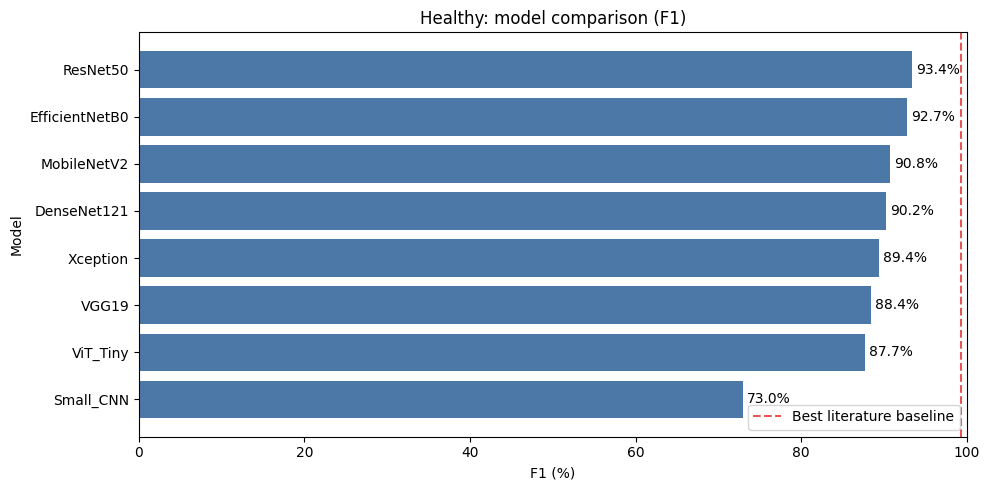

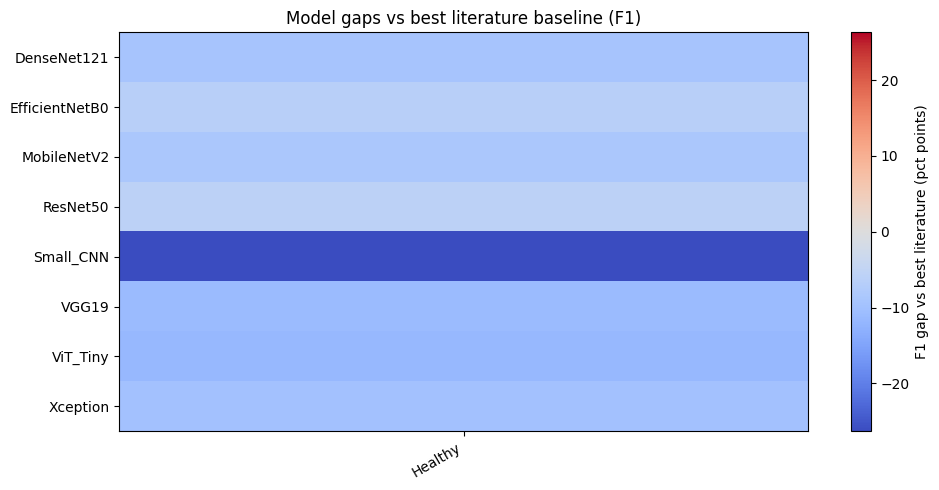

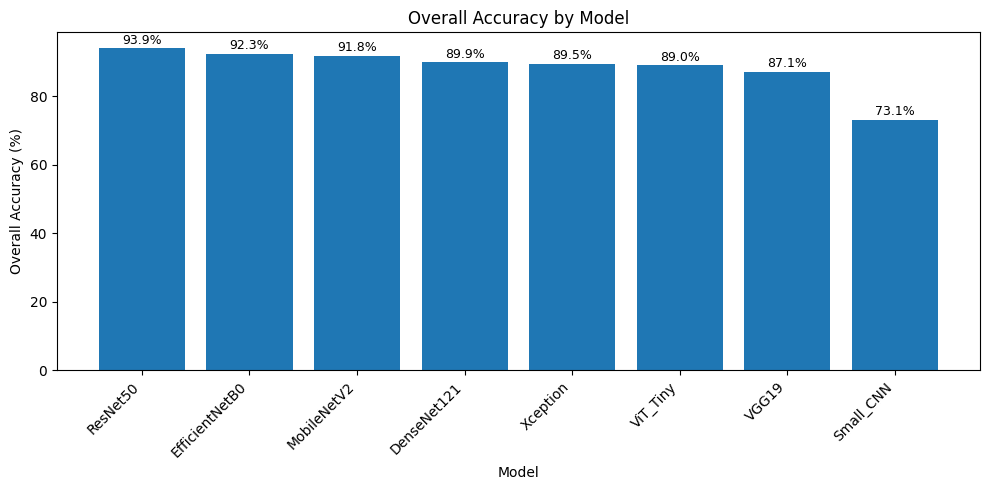

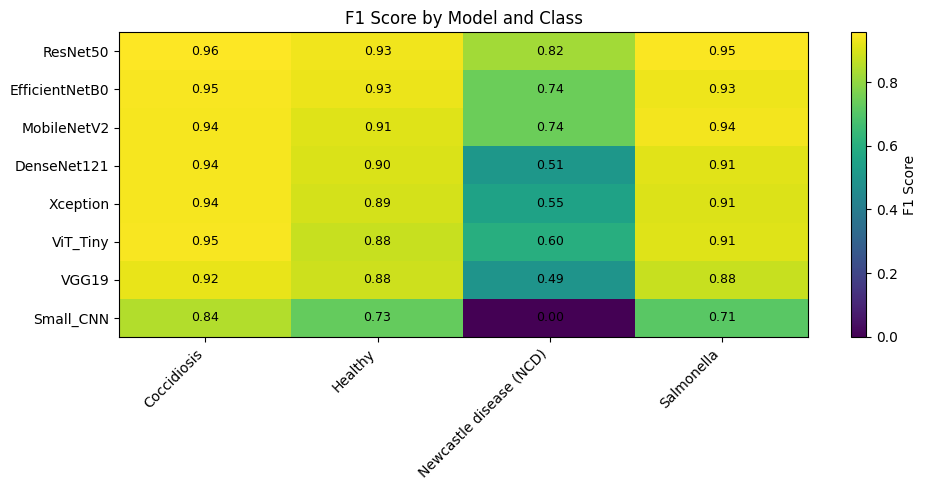

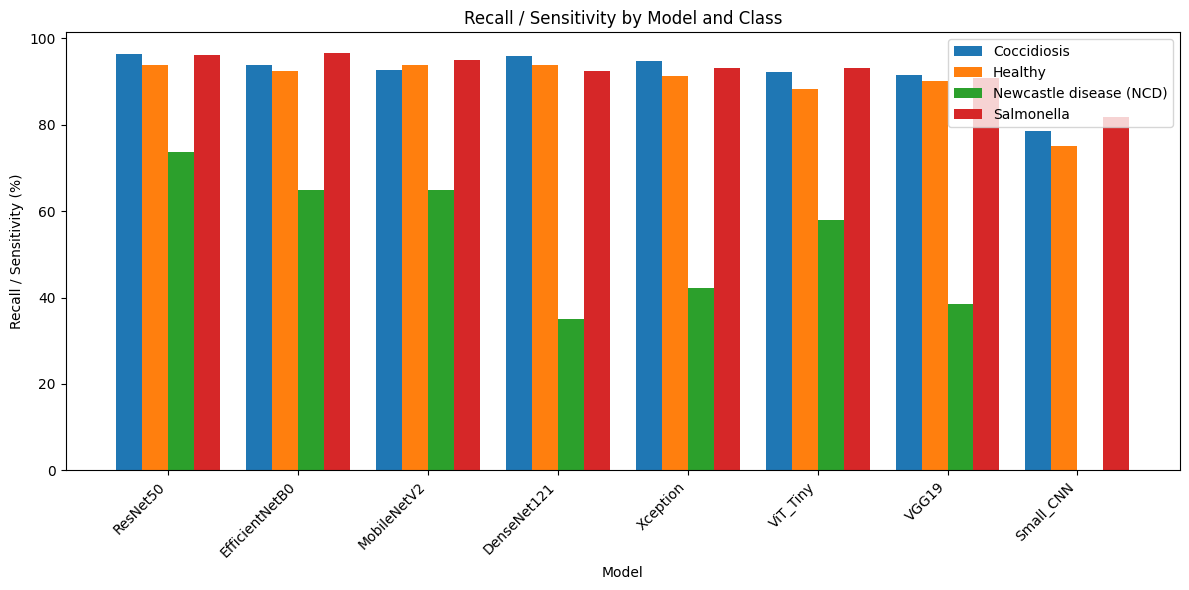

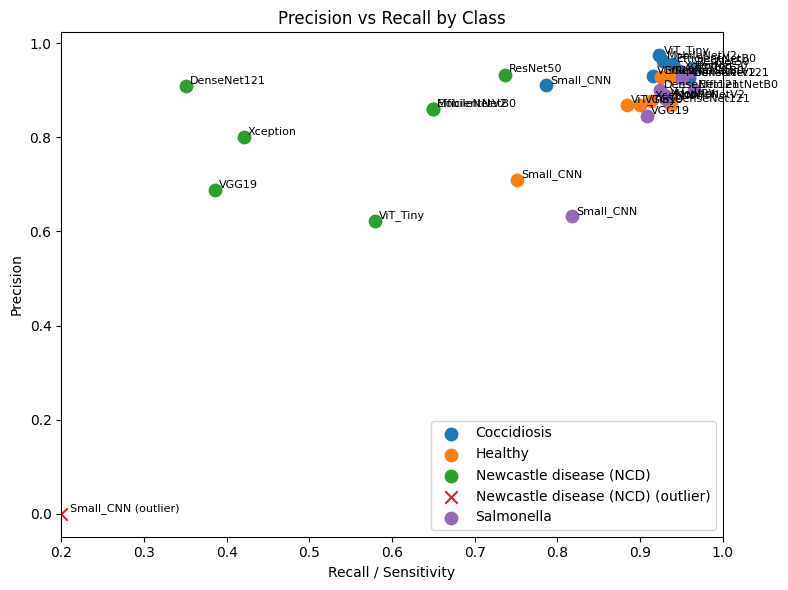

In [22]:
# Visual comparisons of trained models per disease vs literature baselines
# Set CSV_OUTPUT_DIR to an existing experiment folder to plot from saved CSVs.
CSV_OUTPUT_DIR = OUTPUT_DIR
metric = "F1"
metric_label = f"{metric} (%)"

class_metrics_csv = Path(f"{CSV_OUTPUT_DIR}/prototype_per_class_metrics.csv")
baseline_csv = Path(f"{CSV_OUTPUT_DIR}/literature_disease_level_baselines.csv")

if class_metrics_csv.exists():
    class_metrics_df = pd.read_csv(class_metrics_csv)
if baseline_csv.exists():
    disease_baseline_df = pd.read_csv(baseline_csv)

if "class_metrics_df" not in globals():
    class_metrics_df = (
        results_df
        .groupby(["Model", "Class"], as_index=False)
        .agg(
            Precision=("Precision", "mean"),
            Recall_Sensitivity=("Recall_Sensitivity", "mean"),
            Specificity=("Specificity", "mean"),
            F1=("F1", "mean"),
            Support=("Support", "sum"),
        )
    )

if "disease_baseline_df" not in globals():
    disease_baseline_df = pd.DataFrame(disease_literature_baselines)
    for col in ["Precision", "Recall", "F1"]:
        disease_baseline_df[f"{col}_Percent"] = disease_baseline_df[col] * 100

prototype_class_to_disease = {
    "healthy": "Healthy",
    "cocci": "Coccidiosis",
    "ncd": "Newcastle disease (NCD)",
    "salmo": "Salmonella",
}

plot_df = class_metrics_df.copy()
plot_df["Disease"] = (
    plot_df["Class"].astype(str).str.strip().str.lower().map(prototype_class_to_disease)
 )
plot_df = plot_df[plot_df["Disease"].notna()].copy()

baseline_df = (
    disease_baseline_df
    .sort_values(metric, ascending=False)
    .groupby("Disease", as_index=False)
    .first()[["Disease", metric]]
    .rename(columns={metric: f"Baseline_{metric}"})
)

plot_df = plot_df.merge(baseline_df, on="Disease", how="left")
plot_df[f"{metric}_Percent"] = plot_df[metric] * 100
plot_df[f"Baseline_{metric}_Percent"] = plot_df[f"Baseline_{metric}"] * 100
plot_df[f"Gap_{metric}_Percent"] = (plot_df[metric] - plot_df[f"Baseline_{metric}"]) * 100

for disease in sorted(plot_df["Disease"].unique()):
    disease_df = plot_df[plot_df["Disease"] == disease].sort_values(metric, ascending=True)

    plt.figure(figsize=(10, 5))
    plt.barh(disease_df["Model"], disease_df[f"{metric}_Percent"], color="#4C78A8")
    plt.xlabel(metric_label)
    plt.ylabel("Model")
    plt.title(f"{disease}: model comparison ({metric})")
    plt.xlim(0, 100)

    baseline_values = disease_df[f"Baseline_{metric}_Percent"].dropna()
    if not baseline_values.empty:
        baseline_value = float(baseline_values.iloc[0])
        plt.axvline(baseline_value, color="#E45756", linestyle="--", label="Best literature baseline")
        plt.legend(loc="lower right")

    for i, value in enumerate(disease_df[f"{metric}_Percent"]):
        plt.text(value + 0.5, i, f"{value:.1f}%", va="center")

    plt.tight_layout()
    plt.show()

#Heatmap of model gaps vs best literature baseline per disease
gap_pivot = plot_df.pivot_table(
    index="Model",
    columns="Disease",
    values=f"Gap_{metric}_Percent",
    aggfunc="mean",
).sort_index()

plt.figure(figsize=(10, 5))
max_abs = float(np.nanmax(np.abs(gap_pivot.values))) if gap_pivot.size else 1.0
plt.imshow(gap_pivot.values, cmap="coolwarm", vmin=-max_abs, vmax=max_abs, aspect="auto")
plt.colorbar(label=f"{metric} gap vs best literature (pct points)")
plt.xticks(range(len(gap_pivot.columns)), gap_pivot.columns, rotation=30, ha="right")
plt.yticks(range(len(gap_pivot.index)), gap_pivot.index)
plt.title(f"Model gaps vs best literature baseline ({metric})")
plt.tight_layout()
plt.show()

# Additional summary charts using the per-class CSV
df = class_metrics_df.copy()
if "Overall_Accuracy" not in df.columns:
    if "overall_results" in globals():
        df = df.merge(
            overall_results[["Model", "Overall_Accuracy"]],
            on="Model",
            how="left",
        )
    elif "results_df" in globals() and "Overall_Accuracy" in results_df.columns:
        df = df.merge(
            results_df[["Model", "Overall_Accuracy"]].drop_duplicates(),
            on="Model",
            how="left",
        )

if "Overall_Accuracy" in df.columns:
    overall_df = df[["Model", "Overall_Accuracy"]].drop_duplicates().sort_values(
        "Overall_Accuracy",
        ascending=False,
    )
    plt.figure(figsize=(10, 5))
    plt.bar(overall_df["Model"], overall_df["Overall_Accuracy"] * 100)
    plt.ylabel("Overall Accuracy (%)")
    plt.xlabel("Model")
    plt.title("Overall Accuracy by Model")
    plt.xticks(rotation=45, ha="right")

    for i, value in enumerate(overall_df["Overall_Accuracy"] * 100):
        plt.text(i, value + 0.5, f"{value:.1f}%", ha="center", va="bottom", fontsize=9)

    plt.tight_layout()
    plt.show()

f1_pivot = df.pivot(index="Model", columns="Class", values="F1")
if "Overall_Accuracy" in df.columns:
    f1_pivot = f1_pivot.loc[overall_df["Model"]]

fig, ax = plt.subplots(figsize=(10, 5))
im = ax.imshow(f1_pivot.values, aspect="auto")
ax.set_xticks(np.arange(len(f1_pivot.columns)))
ax.set_yticks(np.arange(len(f1_pivot.index)))
ax.set_xticklabels(f1_pivot.columns, rotation=45, ha="right")
ax.set_yticklabels(f1_pivot.index)
ax.set_title("F1 Score by Model and Class")
for i in range(f1_pivot.shape[0]):
    for j in range(f1_pivot.shape[1]):
        value = f1_pivot.iloc[i, j]
        ax.text(j, i, f"{value:.2f}", ha="center", va="center", fontsize=9)
fig.colorbar(im, ax=ax, label="F1 Score")
plt.tight_layout()
plt.show()

recall_pivot = df.pivot(index="Model", columns="Class", values="Recall_Sensitivity")
if "Overall_Accuracy" in df.columns:
    recall_pivot = recall_pivot.loc[overall_df["Model"]]

x = np.arange(len(recall_pivot.index))
classes = recall_pivot.columns
width = 0.2
plt.figure(figsize=(12, 6))
for i, cls in enumerate(classes):
    plt.bar(x + i * width, recall_pivot[cls] * 100, width=width, label=cls)
plt.xticks(x + width * (len(classes)-1) / 2, recall_pivot.index, rotation=45, ha="right")
plt.ylabel("Recall / Sensitivity (%)")
plt.xlabel("Model")
plt.title("Recall / Sensitivity by Model and Class")
plt.legend()
plt.tight_layout()
plt.show()

classes = df["Class"].unique()
plt.figure(figsize=(8, 6))
for cls in classes:
    subset = df[df["Class"] == cls]
    outlier_mask = subset["Recall_Sensitivity"] < 0.2
    main_subset = subset[~outlier_mask]
    if not main_subset.empty:
        plt.scatter(main_subset["Recall_Sensitivity"], main_subset["Precision"], label=cls, s=80)
        for _, row in main_subset.iterrows():
            plt.text(
                row["Recall_Sensitivity"] + 0.005,
                row["Precision"] + 0.005,
                row["Model"],
                fontsize=8,
            )
    if outlier_mask.any():
        outliers = subset[outlier_mask]
        plt.scatter([0.2] * len(outliers), outliers["Precision"], label=f"{cls} (outlier)", s=80, marker="x")
        for _, row in outliers.iterrows():
            plt.text(0.21, row["Precision"] + 0.005, f"{row['Model']} (outlier)", fontsize=8)
plt.xlabel("Recall / Sensitivity")
plt.ylabel("Precision")
plt.title("Precision vs Recall by Class")
plt.xlim(0.2, 1.0)
plt.legend()
plt.tight_layout()
plt.show()
